In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
try:
    df = pd.read_csv('movie_data.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'movie_data.csv' not found. Please ensure the file is in the correct directory.")
    exit()

Dataset loaded successfully!


In [5]:
print("\n--- Dataset Summary ---")
print(df.info())


--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5043 non-null   int64  
 1   director_name         4939 non-null   object 
 2   duration              5028 non-null   float64
 3   actor_2_name          5030 non-null   object 
 4   genres                5043 non-null   object 
 5   actor_1_name          5036 non-null   object 
 6   movie_title           5043 non-null   object 
 7   num_voted_users       5043 non-null   int64  
 8   actor_3_name          5020 non-null   object 
 9   movie_imdb_link       5043 non-null   object 
 10  num_user_for_reviews  5022 non-null   float64
 11  language              5029 non-null   object 
 12  country               5038 non-null   object 
 13  title_year            4935 non-null   float64
 14  imdb_score            5043 non-null   float64
d

Saved: imdb_score_distribution.png


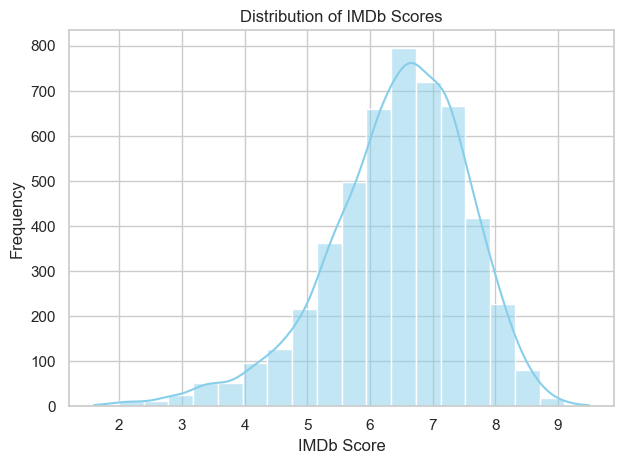

In [6]:
plt.clf()
sns.histplot(df['imdb_score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('imdb_score_distribution.png', bbox_inches='tight')
print("Saved: imdb_score_distribution.png")

In [7]:
plt.clf()

<Figure size 640x480 with 0 Axes>

In [8]:
director_stats = df.groupby('director_name').agg(
    avg_score=('imdb_score', 'mean'),
    movie_count=('movie_title', 'count')
).reset_index()

Saved: top_directors.png


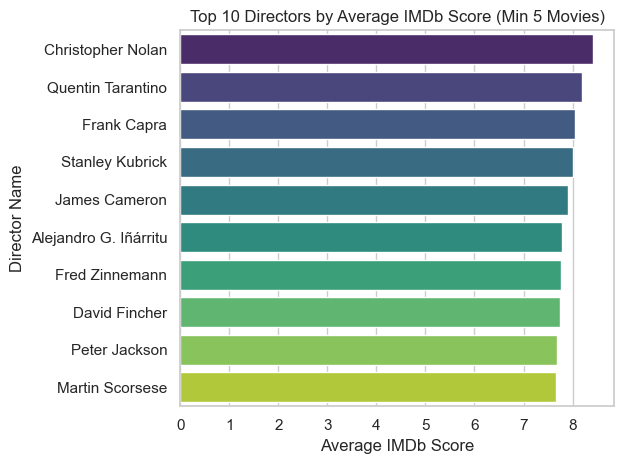

In [9]:
top_directors = director_stats[director_stats['movie_count'] >= 5].sort_values(by='avg_score', ascending=False).head(10)

sns.barplot(data=top_directors, x='avg_score', y='director_name', palette='viridis', hue='director_name')
plt.title('Top 10 Directors by Average IMDb Score (Min 5 Movies)')
plt.xlabel('Average IMDb Score')
plt.ylabel('Director Name')
plt.tight_layout()
plt.savefig('top_directors.png', bbox_inches='tight')
print("Saved: top_directors.png")

In [10]:
plt.clf()

<Figure size 640x480 with 0 Axes>

Saved: imdb_vs_duration.png


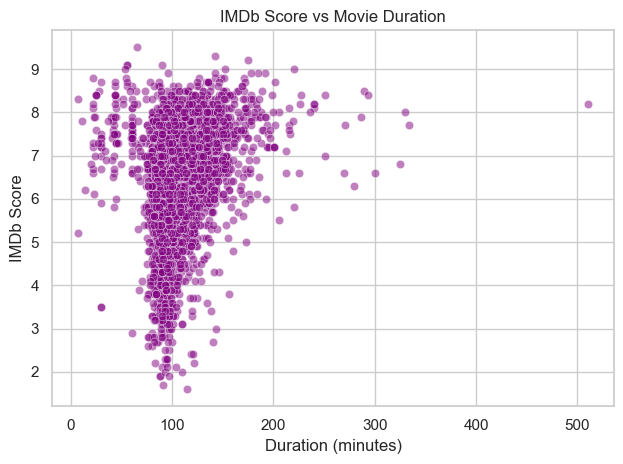

In [11]:
df_cleaned = df.dropna(subset=['duration', 'imdb_score'])

sns.scatterplot(data=df_cleaned, x='duration', y='imdb_score', alpha=0.5, color='purple')
plt.title('IMDb Score vs Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('IMDb Score')
plt.tight_layout()
plt.savefig('imdb_vs_duration.png', bbox_inches='tight')
print("Saved: imdb_vs_duration.png")

In [12]:
plt.clf()
df_year = df.dropna(subset=['title_year']).copy()
df_year['title_year'] = df_year['title_year'].astype(int)

<Figure size 640x480 with 0 Axes>

Saved: movies_per_year.png


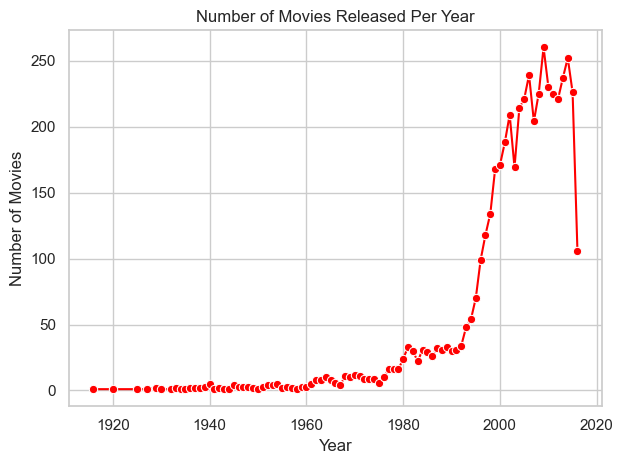

In [13]:
year_counts = df_year['title_year'].value_counts().sort_index().reset_index()
year_counts.columns = ['Year', 'Movie Count']

sns.lineplot(data=year_counts, x='Year', y='Movie Count', marker='o', color='red')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movies_per_year.png', bbox_inches='tight')
print("Saved: movies_per_year.png")

In [14]:
plt.clf()

<Figure size 640x480 with 0 Axes>

In [15]:
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split('|')
df_exploded = df_genres.explode('genres')

genre_stats = df_exploded.groupby('genres').agg(
    avg_score=('imdb_score', 'mean'),
    movie_count=('movie_title', 'count')
).reset_index()

Saved: genre_ratings.png


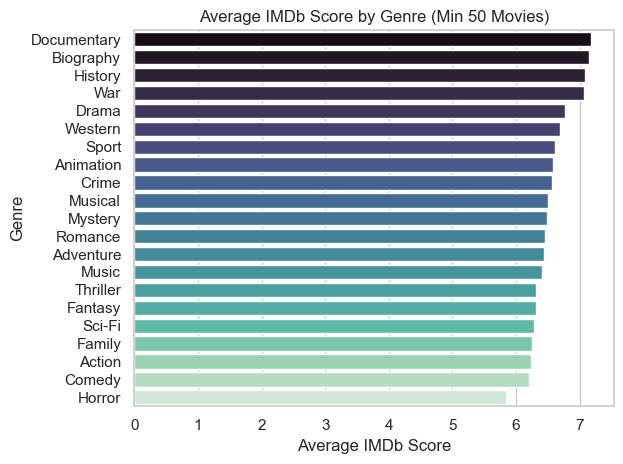

In [16]:
top_genres = genre_stats[genre_stats['movie_count'] >= 50].sort_values(by='avg_score', ascending=False)

sns.barplot(data=top_genres, x='avg_score', y='genres', palette='mako', hue='genres')
plt.title('Average IMDb Score by Genre (Min 50 Movies)')
plt.xlabel('Average IMDb Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_ratings.png', bbox_inches='tight')
print("Saved: genre_ratings.png")

In [17]:
print("\n--- Correlation Metrics ---")
numeric_cols = ['duration', 'num_voted_users', 'num_user_for_reviews', 'imdb_score', 'title_year']
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)


--- Correlation Metrics ---
                      duration  num_voted_users  num_user_for_reviews  \
duration              1.000000         0.314765              0.328403   
num_voted_users       0.314765         1.000000              0.798406   
num_user_for_reviews  0.328403         0.798406              1.000000   
imdb_score            0.261662         0.410965              0.292475   
title_year           -0.135038         0.007397             -0.003147   

                      imdb_score  title_year  
duration                0.261662   -0.135038  
num_voted_users         0.410965    0.007397  
num_user_for_reviews    0.292475   -0.003147  
imdb_score              1.000000   -0.209167  
title_year             -0.209167    1.000000  
